In [65]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding , Dense , GRU , LSTM , SimpleRNN
from tensorflow.keras import Sequential
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences
from re import VERBOSE

In [66]:
corpus = '''
Antonio was a merchant of great reputation in the city, known not only for his wealth but also for his quiet generosity. Though his ships sailed across distant seas carrying silks and spices, his mind often wandered beyond trade and profit. Bassanio, his dear friend, sought his counsel often, speaking of dreams, fortunes, and the pursuit of love.
In the busy streets of Venice, where voices echoed between stone walls and the canals shimmered under the fading sun, stories of risk and reward unfolded each day. Merchants bargained with urgency, sailors spoke of storms and distant lands, and the air carried both hope and uncertainty. Antonio, however, seemed untouched by the excitement, as if a shadow lingered within him that no gold could dispel.
One evening, as the bells tolled softly across the water, Bassanio approached Antonio with a request. He spoke of a lady of great wisdom and beauty, whose presence alone could calm the restless heart. Yet to reach her, he required means beyond his own. Without hesitation, Antonio agreed to help, for friendship weighed more heavily in his heart than caution.
Thus began a chain of events that would test loyalty, challenge judgment, and reveal the true nature of mercy and justice. In a world governed by contracts and coin, the question remained whether compassion could prevail over strict demands. And as their fates intertwined, each choice carried consequences that neither could fully foresee.
'''

In [67]:
print(len(corpus))

1456


In [68]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocubalary Size :" ,total_words)

Vocubalary Size : 165


In [69]:
input_sequence = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
      n_gram_sequence = token_list[:i+1]
      input_sequence.append(n_gram_sequence)
max_len = max([len(x) for x in input_sequence])
input_sequence = pad_sequences(input_sequence, maxlen=max_len, padding='pre')
X = input_sequence[:, :-1]
y = input_sequence[:, -1]
print("X shape :", X.shape)
print("y shape :" ,y.shape)

X shape : (233, 65)
y shape : (233,)


In [70]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),# change the dimension of output from 32 to 64
    SimpleRNN(128), # changed hidden units from 64 to 128
    Dense(total_words , activation="softmax")
])
rnn_model.compile(loss = 'sparse_categorical_crossentropy',
            optimizer = 'adam', metrics =['accuracy'])
rnn_history = rnn_model.fit(X,y,epochs = 200 , verbose = 0) # increased the epoch from 100 to 200
print("Model Trained completed :")

Model Trained completed :


In [71]:
LSTM_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),# change the dimension of output from 32 to 64
    LSTM(128), # changed hidden units from 64 to 128
    Dense(total_words , activation="softmax")
])
LSTM_model.compile(loss = 'sparse_categorical_crossentropy',
            optimizer = 'adam', metrics =['accuracy'])
LSTM_history = LSTM_model.fit(X,y,epochs = 200 , verbose = 0)#epoch increased from 100 to 200
print("Training of Lstm is completed :")

Training of Lstm is completed :


In [72]:
GRU_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),# change the dimension of output from 32 to 64
    GRU(128), # changed hidden units from 64 to 128
    Dense(total_words , activation="softmax")
])
GRU_model.compile(loss ='sparse_categorical_crossentropy' , optimizer = 'adam' , metrics =['accuracy'])
GRU_history = GRU_model.fit(X,y,epochs = 200 , verbose = 0) #epoch increased from 100 to 200
print("GRU is trained")

GRU is trained


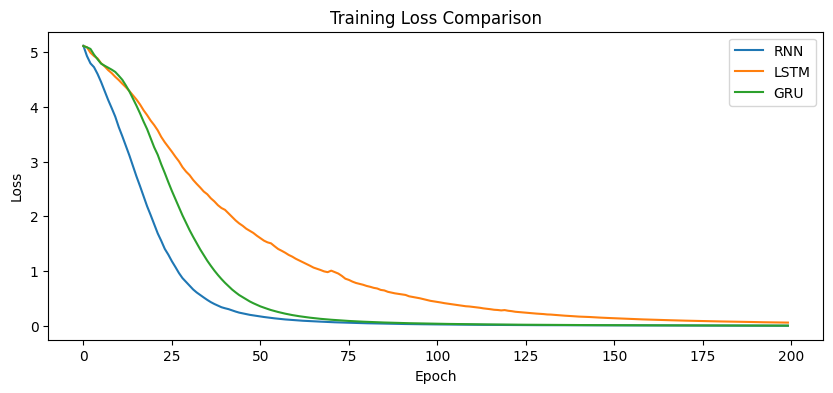

In [73]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(LSTM_history.history['loss'], label='LSTM')
plt.plot(GRU_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

In [74]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

In [75]:
print("RNN :", generate_text(rnn_model , "if" , 10))

RNN : if began a chain of events that would test loyalty challenge


In [76]:
print("LSTM :", generate_text(LSTM_model , "if" , 10))

LSTM : if a chain of events that would test loyalty challenge judgment


In [78]:
print("GRU :", generate_text(GRU_model , "if" , 10))

GRU : if a merchant of great reputation in the city known not


**Conclusion**
1. RNN learns fastest but overfits — it memorizes short patterns and fails to capture long-term dependencies.
2. LSTM performs best for sequence learning — its gating mechanism helps retain important context over long sequences.
3. GRU provides similar performance to LSTM — but with fewer parameters, making it faster and more efficient.
4. Overall, LSTM and GRU outperform RNN — especially for meaningful text generation and handling long-term dependencies